
# Geometry-Aware Mixture of Experts (GAMoE)
## Modular Manifold Factorization, Feature Attribution, and Structural Ablations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PridaLab/gamoe_model/blob/main/notebooks/gamoe_simulated_example.ipynb)

This notebook demonstrates the end-to-end mathematical, algorithmic, and visual pipeline for **Geometry-Aware Mixture of Experts (GAMoE)** applied to an arbitrary multi-channel system:
1. **Latent Manifold & Multi-Channel Driver Simulation**: Synthesizes a non-linear latent manifold $\mathcal{M} \subset \mathbb{R}^D$ driven by global basis channels, localized functional receptive fields, and observable state variables.
2. **Exploratory Data Analysis (EDA)**: Analyzes raw channel distributions, activation sparsity, and cross-channel correlations.
3. **Topological Structure Index ($SI$)**: Quantifies whether continuous variables cluster along the manifold surface.
4. **GAMoE Model Training**: Fits bottleneck expert networks $f_j(x_j)$ guided by Gaussian geometric density priors $g_j(\mathbf{u})$.
5. **Model Diagnostics**: Evaluates 1D expert response curves, input weight norms, and effective output variance.
6. **Systematic Test-Time Ablations**: Assesses functional necessity vs. geometric routing dependence via **Gate Drop** and **Gate Shuffling**, visualized with spatial residual error maps.

In [5]:
# ==============================================================================
# Step 0: Environment Setup for Google Colab / Local Execution
# ==============================================================================
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Google Colab environment.")
    REPO_NAME = "gamoe_model"
    REPO_URL = f"https://github.com/PridaLab/{REPO_NAME}.git"
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}
    %cd {REPO_NAME}
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())
    !pip install -q -r requirements.txt
    print("Environment configured.")
else:
    print("Running in a local environment.")
    if ".." not in sys.path:
        sys.path.append("..")

Running in a local environment.


In [6]:
# ==============================================================================
# Step 1: Core Imports & Reproducibility
# ==============================================================================
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.spatial import distance_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
%matplotlib inline

print(f"Device: {device}")

Device: cpu


## Theory: Geometric Priors, Metric Scoring, & Topological Structure

### 1. Manifold Reconstruction via Geometry-Aware Mixture of Experts
Let $\mathbf{x} = [x_1, x_2, \dots, x_N]^T \in \mathbb{R}^N$ be a multi-channel feature vector, and let $\mathbf{u} \in \mathbb{R}^D$ be low-dimensional coordinates on a target manifold $\mathcal{M}$.

GAMoE decomposes the mapping by allocating an independent bottleneck expert $f_j(x_j)$ ($1 \to H \to \text{ReLU} \to D$) to each channel $x_j$. The reconstructed manifold position $\hat{\mathbf{u}}$ is a geometry-gated combination:
$$\hat{\mathbf{u}} = \sum_{j=1}^{N} g_j(\mathbf{u}) \cdot f_j(x_j)$$

### 2. Gaussian Geometric Priors
The gating coefficients $g_j(\mathbf{u})$ are derived from spatial density priors over the manifold coordinates. For each channel $j$, its center $\boldsymbol{\mu}_j$ and covariance $\boldsymbol{\Sigma}_j$ in manifold space are estimated via weighted moments:
$$\boldsymbol{\mu}_j = \frac{\sum_{i=1}^M w_{ij} \mathbf{u}_i}{\sum_{i=1}^M w_{ij}}, \qquad \boldsymbol{\Sigma}_j = \frac{\sum_{i=1}^M w_{ij} (\mathbf{u}_i - \boldsymbol{\mu}_j)(\mathbf{u}_i - \boldsymbol{\mu}_j)^T}{\sum_{i=1}^M w_{ij}} + \epsilon \mathbf{I}$$

where $w_{ij} = \max(0, x_{ij})$ and $\epsilon > 0$ provides numerical regularization. Given sample coordinates $\mathbf{u}$, the prior density and normalized gate are:
$$Q_{ij} = \mathcal{N}(\mathbf{u}; \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j) = \frac{1}{\sqrt{(2\pi)^D \det(\boldsymbol{\Sigma}_j)}} \exp\left(-\frac{1}{2}(\mathbf{u} - \boldsymbol{\mu}_j)^T \boldsymbol{\Sigma}_j^{-1} (\mathbf{u} - \boldsymbol{\mu}_j)\right)$$
$$g_j(\mathbf{u}) = \frac{Q_{ij}^\alpha}{\sum_{k=1}^N Q_{ik}^\alpha}, \qquad \sum_{j=1}^N g_j(\mathbf{u}) = 1$$
The exponent $\alpha \ge 1$ controls gating sharpness.

### 3. Variance-Weighted Global $R^2$
To evaluate multi-dimensional manifold reconstruction without penalizing axes with low intrinsic variance, we compute a variance-weighted global $R^2$:
$$R^2_d = \left( \frac{\text{Cov}(\mathbf{u}_d, \hat{\mathbf{u}}_d)}{\sigma_{\mathbf{u}_d} \sigma_{\hat{\mathbf{u}}_d}} \right)^2, \qquad R^2_{\text{global}} = \sum_{d=1}^D w_d R^2_d, \quad w_d = \frac{\text{Var}(\mathbf{u}_d)}{\sum_{k=1}^D \text{Var}(\mathbf{u}_k)}$$

### 4. Topological Structure Index ($SI$) Cite
The Structure Index measures whether a continuous variable $y$ (input activation, gate probability, or reconstruction error) is localized along the manifold topology. 
Normalized such that $SI = 0$ corresponds to random spatial dispersion and $SI = 1$ indicates perfect topological localization.

In [7]:
# ==============================================================================
# Step 2: Core Geometric Priors and Evaluation Functions
# ==============================================================================
def weighted_mean_cov(X, w):
    """Compute sample-weighted mean and covariance matrix in manifold coordinates."""
    w = np.clip(w, 0, None)
    s = w.sum() + 1e-12
    m = (X * w[:, None]).sum(0) / s
    diff = (X - m) * np.sqrt(w[:, None])
    C = (diff.T @ diff) / s + 1e-6 * np.eye(X.shape[1])
    return m, C

def gaussian_pdf(X, mean, cov):
    """Evaluate multivariate Gaussian probability density function."""
    inv, det = np.linalg.inv(cov), np.linalg.det(cov)
    diff = X - mean
    norm = 1.0 / np.sqrt(((2 * np.pi) ** X.shape[1]) * det)
    ex = np.einsum("ni,ij,nj->n", diff, inv, diff)
    return norm * np.exp(-0.5 * ex)

def build_geometry_prior(U_coords, W_activity):
    """Construct geometry-aware prior mapping from manifold space to experts."""
    comps = []
    n_features = W_activity.shape[1]
    for j in range(n_features):
        wj = W_activity[:, j]
        if np.allclose(wj.sum(), 0):
            m, C = U_coords.mean(0), np.cov(U_coords.T) + 1e-6 * np.eye(U_coords.shape[1])
        else:
            m, C = weighted_mean_cov(U_coords, wj)
        comps.append((m, C))

    def prior_evaluator(U_eval):
        D = np.zeros((U_eval.shape[0], n_features))
        for j, (m, C) in enumerate(comps):
            D[:, j] = gaussian_pdf(U_eval, m, C)
        D += 1e-12
        return D / D.sum(1, keepdims=True)

    return prior_evaluator

def compute_corr_r2_scores(U_true, U_pred, eps=1e-12):
    """Variance-weighted global R² and dimension-specific Pearson scores."""
    U_true, U_pred = np.asarray(U_true), np.asarray(U_pred)
    D = U_true.shape[1]
    r_dims, r2_dims = [], []
    for d in range(D):
        x, y = U_true[:, d], U_pred[:, d]
        sx, sy = x.std(), y.std()
        r = 0.0 if (sx < eps or sy < eps) else np.corrcoef(x, y)[0, 1]
        r = 0.0 if np.isnan(r) else r
        r_dims.append(float(r))
        r2_dims.append(float(r**2))
    vars_ = U_true.var(axis=0)
    w = vars_ / (vars_.sum() + eps)
    r2_global = float((w * np.array(r2_dims)).sum())
    return r2_global, r2_dims, r_dims

def compute_structure_index(data, label, n_bins=8, k=10, num_shuffles=20):
    """Calculate topological Structure Index (SI) across manifold partitions."""
    data, label = np.asarray(data), np.asarray(label).flatten()
    bins = np.linspace(np.percentile(label, 2), np.percentile(label, 98), n_bins + 1)
    bin_labels = np.digitize(label, bins) - 1
    valid = (bin_labels >= 0) & (bin_labels < n_bins)
    data, bin_labels = data[valid], bin_labels[valid]
    ubins = np.unique(bin_labels)
    nb = len(ubins)
    if nb <= 1:
        return 0.0, np.zeros(num_shuffles)

    def calc_overlap(pts, lbls):
        D = distance_matrix(pts, pts)
        np.fill_diagonal(D, np.inf)
        mat = np.zeros((nb, nb))
        for i, b1 in enumerate(ubins):
            idx1 = np.where(lbls == b1)[0]
            if len(idx1) == 0: continue
            for j, b2 in enumerate(ubins):
                if i == j: continue
                idx2 = np.where(lbls == b2)[0]
                if len(idx2) == 0: continue
                knn = np.argsort(D[idx1], axis=1)[:, :k]
                mat[i, j] = np.mean(np.isin(knn, idx2))
        deg = np.sum(mat, axis=1)
        si = 1.0 - np.mean(deg) / (nb - 1 + 1e-12)
        return float(np.clip(2 * (si - 0.5), 0, 1))

    si_actual = calc_overlap(data, bin_labels)
    shuf_scores = []
    perm_lbls = bin_labels.copy()
    for _ in range(num_shuffles):
        np.random.shuffle(perm_lbls)
        shuf_scores.append(calc_overlap(data, perm_lbls))
    return si_actual, np.array(shuf_scores)

## Theory: Constrained Bottleneck Mixture of Experts

### Independent Channel Factorization
GAMoE constrains each expert to process only its corresponding scalar channel:
- **Expert $j$** is a MultiLayerPercepton : 
  $$f_j(x_j) = \mathbf{W}_{2, j} \,\text{ReLU}(\mathbf{W}_{1, j} x_j + \mathbf{b}_{1, j}) + \mathbf{b}_{2, j}$$
  where $\mathbf{W}_{1, j} \in \mathbb{R}^{H \times 1}$ and $\mathbf{W}_{2, j} \in \mathbb{R}^{D \times H}$ ($H$ is the hidden dimension, default $11$).
- **Gated Recombination**:
  $$\hat{\mathbf{u}} = \sum_{j=1}^N g_j(\mathbf{u}) \cdot f_j(x_j)$$

This decoupling permits test-time ablation of any subset of channels without retraining.

In [9]:
# ==============================================================================
# Step 3: GAMoE Model Architecture Implementation
# ==============================================================================
class ExpertLinearProj(nn.Module):
    def __init__(self, in_dim=1, out_dim=4, hidden=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden, bias=True),
            nn.ReLU(),
            nn.Linear(hidden, out_dim, bias=True),
        )

    def forward(self, x):
        return self.net(x)

class GatedMoE(nn.Module):
    def __init__(self, n_experts=11, out_dim=4, hidden=11):
        super().__init__()
        self.n_experts = n_experts
        self.experts = nn.ModuleList([
            ExpertLinearProj(1, out_dim, hidden=hidden) for _ in range(n_experts)
        ])

    def forward(self, x, gates):
        # x: [B, n_experts], gates: [B, n_experts]
        outs = [exp(x[:, j:j+1]) for j, exp in enumerate(self.experts)]
        outs = torch.stack(outs, dim=2)  # [B, out_dim, n_experts]
        return (outs * gates.unsqueeze(1)).sum(2)

## Theory: Dynamic Parametric Simulation of Multi-Expert Systems

We simulate a system with **$N$ parameterized input channels** and a **$D$-dimensional non-linear manifold** ($D=4$):
1. **Latent Manifold $\mathbf{u}$**: Embedded as a non-linear 2D surface in 4D space with noise $\sigma_{\text{noise}}$:
   $$u_0 = \sin(u) + 0.4\sin(v), \quad u_1 = \cos(u) + 0.4\cos(2v)$$
   $$u_2 = 0.5\sin(u + v), \quad u_3 = 0.5\cos(u - v)$$
2. **Global Basis Channels ($x_1, x_2$)**: Active over the entire manifold with broad modulation and higher variance ($SI \approx 0$).
3. **Localized Functional Channels ($x_3, \dots, x_N$)**: Receptive fields centered at angular positions $\theta_k = \frac{2\pi k}{N - 2}$ along the manifold ring ($SI \to 1$):
   $$x_{ik} = 4.0 \exp\left( -\frac{\Vert{}\mathbf{u}_{i, :2} - \mathbf{c}_k\Vert{}^2}{2\sigma_{\text{rf}}^2} \right) + \text{noise}$$
4. **Observable State Variable $s$**: System covariate correlated with $u_0$ and $u_1$.

> **Customization**: Change `N_EXPERTS` below to any integer (e.g., 6, 12, 16). Downstream plots, architectures, and ablations adjust dynamically.

In [21]:
# ==============================================================================
# Step 4: Generic Multi-Channel Dataset Generation
# ==============================================================================
# CONFIGURE EXPERTS AND DIMENSIONS HERE:
N_EXPERTS = 6
N_SAMPLES = 1200
LATENT_DIM = 4

# Construct generic expert names (2 Global drivers + 3 Modular functional groups)
EXPERT_NAMES = [f"Expert_Global_{i+1}" for i in range(2)]
for i in range(2, N_EXPERTS):
    mod_id = ((i - 2) % 3) + 1
    EXPERT_NAMES.append(f"Expert_Mod{mod_id}_{i-1}")

# 1. Synthesize non-linear 2D surface embedded in 4D
u_coord = np.random.uniform(-np.pi, np.pi, N_SAMPLES)
v_coord = np.random.uniform(-np.pi, np.pi, N_SAMPLES)

U_true = np.zeros((N_SAMPLES, LATENT_DIM))
U_true[:, 0] = np.sin(u_coord) + 0.4 * np.sin(v_coord)
U_true[:, 1] = np.cos(u_coord) + 0.4 * np.cos(2 * v_coord)
U_true[:, 2] = 0.5 * np.sin(u_coord + v_coord)
U_true[:, 3] = 0.5 * np.cos(u_coord - v_coord)

# Additive isotropic noise to simulate diffuse trajectories
MANIFOLD_NOISE_STD = 0.30
U_true += np.random.normal(0, MANIFOLD_NOISE_STD, size=U_true.shape)

# 2. Input channel activations X [N_SAMPLES, N_EXPERTS]
X_raw = np.random.gamma(shape=1.5, scale=0.6, size=(N_SAMPLES, N_EXPERTS))

global_indices = [0, 1]
local_indices = list(range(2, N_EXPERTS))

# A) Global channels: ubiquitous coverage, high baseline, broad drift
for idx in global_indices:
    drift = 2.0 + 0.3 * U_true[:, 0] + 0.2 * U_true[:, 1]
    jitter = np.random.exponential(scale=0.8, size=N_SAMPLES)
    X_raw[:, idx] += drift + jitter

# B) Localized channels: localized Gaussian tuning centers
n_local = len(local_indices)
for k, idx in enumerate(local_indices):
    angle = 2 * np.pi * k / n_local
    c_x, c_y = 0.8 * np.cos(angle), 0.8 * np.sin(angle)
    dist_sq = (U_true[:, 0] - c_x)**2 + (U_true[:, 1] - c_y)**2
    width = 0.45
    drive = 4.0 * np.exp(-dist_sq / (2 * width**2))
    drive[dist_sq > (2.5 * width**2)] *= 0.1
    X_raw[:, idx] += drive

# 3. Continuous system state variable (observable covariate)
covariate_continuous = 100.0 + 20.0 * U_true[:, 0] - 12.0 * U_true[:, 1] + np.random.normal(0, 6.0, N_SAMPLES)

# 4. Train / Test split (75% / 25%)
train_idx, test_idx = train_test_split(np.arange(N_SAMPLES), test_size=0.25, random_state=SEED)
X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
U_train_raw, U_test_raw = U_true[train_idx], U_true[test_idx]
cov_test = covariate_continuous[test_idx]

print(f"Generated dynamic system with N={N_EXPERTS} experts across {N_SAMPLES} samples.")
print(f"  Global Experts: {[EXPERT_NAMES[i] for i in global_indices]}")
print(f"  Localized Experts: {[EXPERT_NAMES[i] for i in local_indices[:3]]} ... (total: {n_local})")

Generated dynamic system with N=6 experts across 1200 samples.
  Global Experts: ['Expert_Global_1', 'Expert_Global_2']
  Localized Experts: ['Expert_Mod1_1', 'Expert_Mod2_2', 'Expert_Mod3_3'] ... (total: 4)


## Theory: Raw Space Exploratory Data Analysis

Before training, we confirm three essential characteristics:
1. **Latent Topologies**: The 2D projection and higher coordinates show continuous geometric structure with realistic noise.
2. **Channel Activations**: Global channels show sustained baseline values; localized channels remain low outside their receptive fields.
3. **Pairwise Covariance**: Functional modules exhibit block-correlated or orthogonal co-activation.

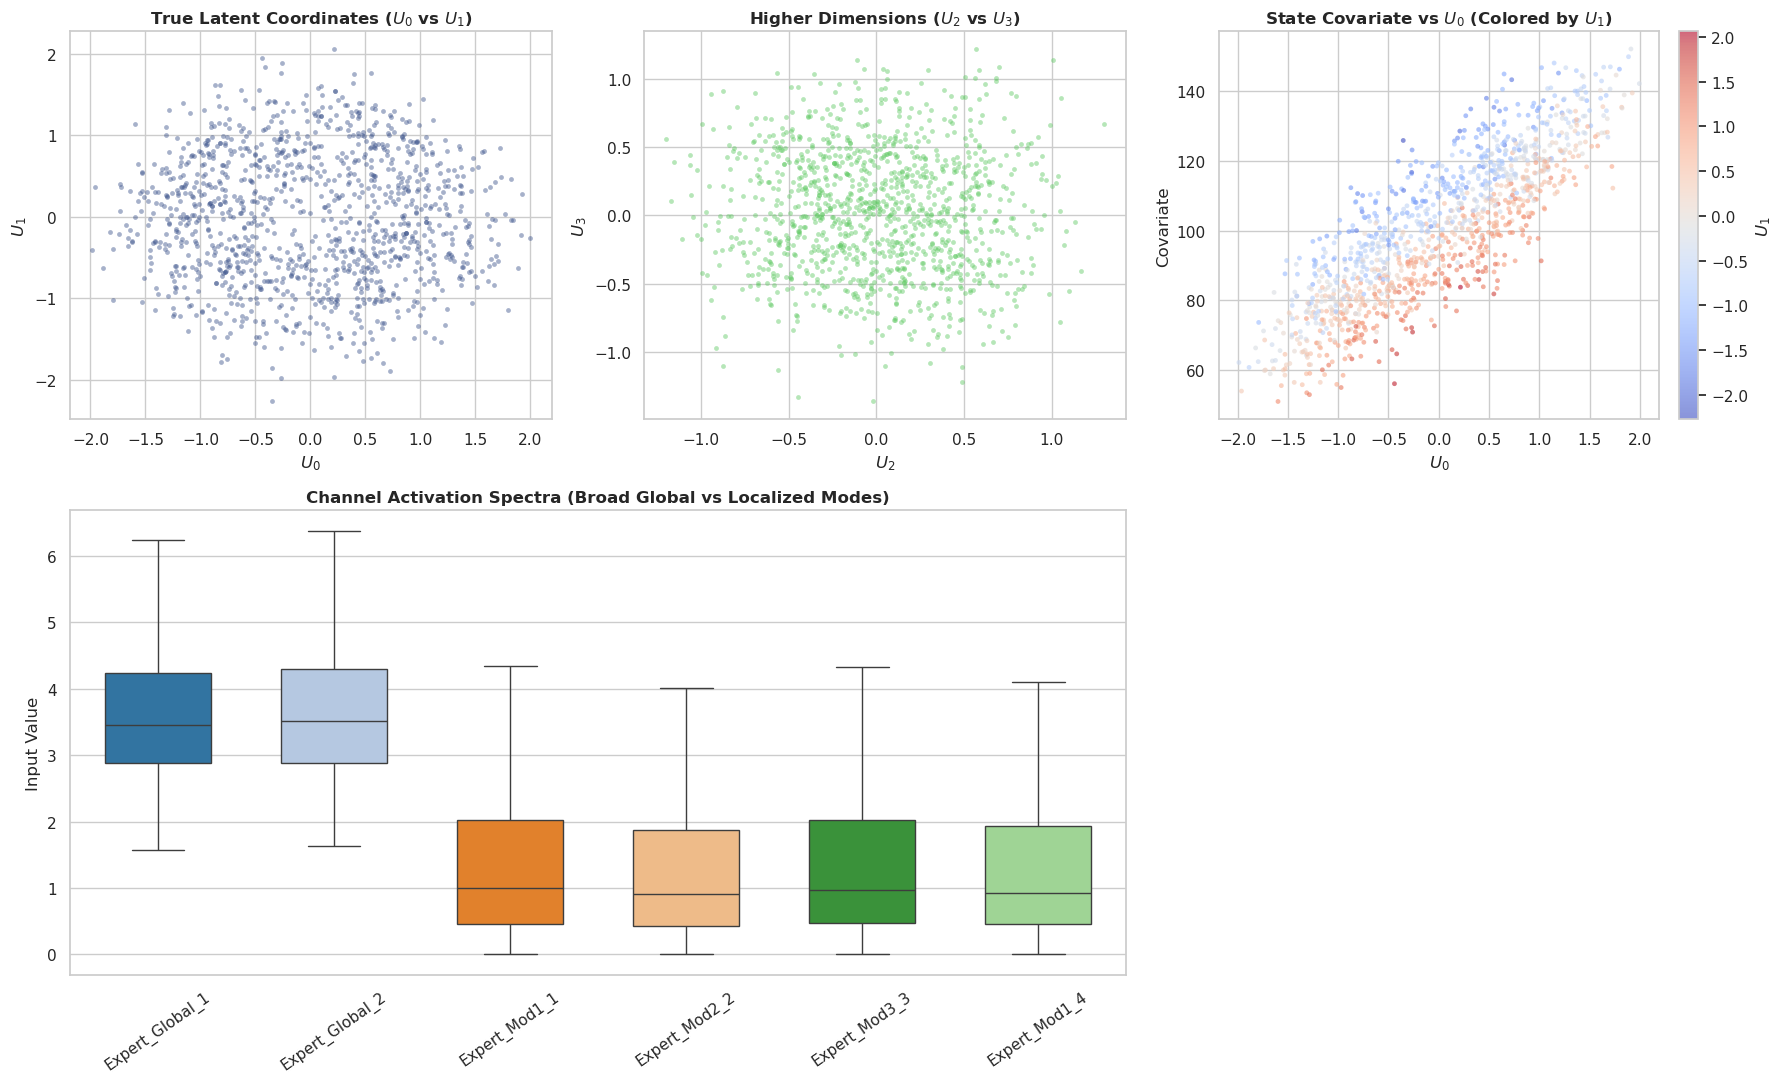

In [22]:
# ==============================================================================
# Step 5: Exploratory Data Analysis (Geometry & Channel Properties)
# ==============================================================================
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2])

# 1. Manifold U0 vs U1
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(U_true[:, 0], U_true[:, 1], c="#3b528b", s=12, alpha=0.45, linewidths=0)
ax1.set_title("True Latent Coordinates ($U_0$ vs $U_1$)", fontweight="bold")
ax1.set_xlabel("$U_0$"); ax1.set_ylabel("$U_1$")

# 2. Manifold U2 vs U3
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(U_true[:, 2], U_true[:, 3], c="#5ec962", s=12, alpha=0.45, linewidths=0)
ax2.set_title("Higher Dimensions ($U_2$ vs $U_3$)", fontweight="bold")
ax2.set_xlabel("$U_2$"); ax2.set_ylabel("$U_3$")

# 3. System Covariate vs U0
ax3 = fig.add_subplot(gs[0, 2])
sc3 = ax3.scatter(U_true[:, 0], covariate_continuous, c=U_true[:, 1], cmap="coolwarm", s=12, alpha=0.6, linewidths=0)
ax3.set_title("State Covariate vs $U_0$ (Colored by $U_1$)", fontweight="bold")
ax3.set_xlabel("$U_0$"); ax3.set_ylabel("Covariate")
cbar3 = fig.colorbar(sc3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label("$U_1$")

# 4. Boxplots of channel activations
ax4 = fig.add_subplot(gs[1, :2])
df_raw = pd.DataFrame(X_raw, columns=EXPERT_NAMES)
sns.boxplot(data=df_raw, orient="v", ax=ax4, palette="tab20", showfliers=False, width=0.6)
ax4.set_title("Channel Activation Spectra (Broad Global vs Localized Modes)", fontweight="bold")
ax4.tick_params(axis="x", rotation=35)
ax4.set_ylabel("Input Value")

plt.tight_layout()
plt.show()

## Theory: Quantifying Localization with the Structure Index ($SI$)

We quantify topological localization for each channel:
- **Global Channels**: Low $SI$ scores (uniform dispersion).
- **Localized Channels**: High $SI$ scores (spatially constrained).

We also evaluate the geometric density prior $g_j(\mathbf{u})$, confirming that the gating distribution concentrates near the spatial centers of each channel's functional receptive field.

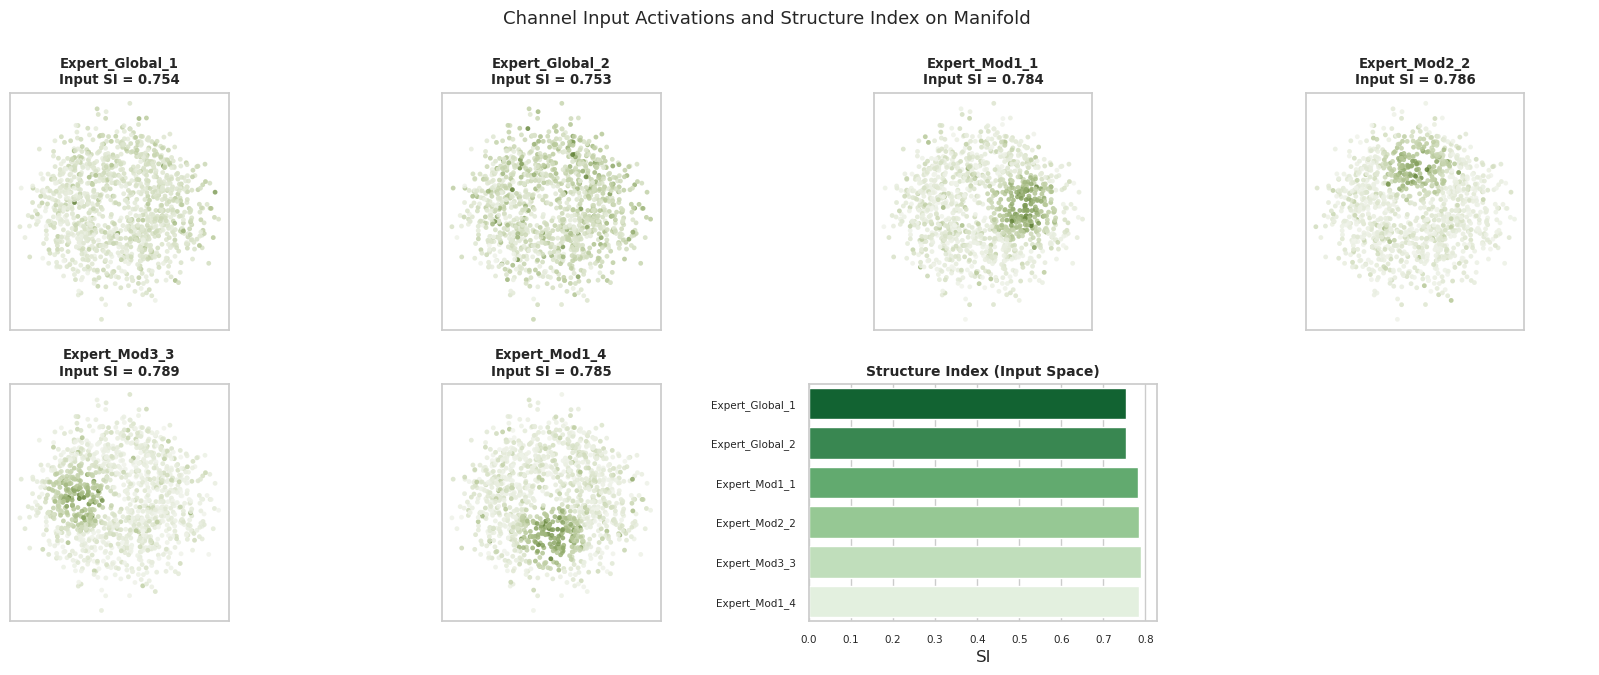

In [23]:
# ==============================================================================
# Step 6: Input SI Calculation & Geometric Density Priors
# ==============================================================================
# 1. Input SI per channel
si_records = []
for i, name in enumerate(EXPERT_NAMES):
    si_val, _ = compute_structure_index(U_true[:, :2], X_raw[:, i], n_bins=8, k=10, num_shuffles=0)
    si_records.append({"channel": name, "SI": si_val})
df_si = pd.DataFrame(si_records)

# 2. Build prior estimator from training data
prior_estimator = build_geometry_prior(U_train_raw, X_train_raw)
Q_all = prior_estimator(U_true)

ALPHA = 2.0
Pf_all = Q_all ** ALPHA
Pf_all /= (Pf_all.sum(1, keepdims=True) + 1e-12)

# Dynamic layout
n_cols = 4
n_panels = N_EXPERTS + 1
n_rows = math.ceil(n_panels / n_cols)

custom_green = LinearSegmentedColormap.from_list(
    "custom_green", ["#f1f4ec", "#d6e0c4", "#b5c796", "#86a25f", "#5f7f34"], N=256
)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows))
axes = axes.ravel()

for i, name in enumerate(EXPERT_NAMES):
    ax = axes[i]
    si_val = df_si.loc[df_si["channel"] == name, "SI"].values[0]
    sc = ax.scatter(U_true[:, 0], U_true[:, 1], c=X_raw[:, i], cmap=custom_green, s=12, alpha=0.85, linewidths=0)
    ax.set_title(f"{name}\nInput SI = {si_val:.3f}", fontsize=9.5, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

# Summary SI Barplot
ax_bar = axes[N_EXPERTS]
sns.barplot(data=df_si, x="SI", y="channel", hue="channel", palette="Greens_r", legend=False, ax=ax_bar)
ax_bar.set_title("Structure Index (Input Space)", fontsize=10, fontweight="bold")
ax_bar.set_xlabel("SI")
ax_bar.set_ylabel("")
ax_bar.tick_params(labelsize=7.5)

for j in range(n_panels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Channel Input Activations and Structure Index on Manifold", fontsize=13, y=0.99)
plt.tight_layout()
plt.show()

## Theory: Model Training via Regularized Bottlenecks

The model is trained via AdamW with Mean Squared Error on scaled coordinates:
$$\mathcal{L}(\mathbf{W}) = \frac{1}{B} \sum_{i=1}^B \left\| \hat{\mathbf{u}}_i(\mathbf{x}_i, g_i) - \mathbf{u}_i \right\|^2 + \lambda \sum_{j=1}^N \|\mathbf{W}_j\|_F^2$$

Because bottleneck projections $f_j(x_j)$ are trained together under the guidance of $g_j(\mathbf{u})$, each expert specializes in reconstructing the coordinate variations corresponding to its assigned spatial domain on the manifold.

In [24]:
# ==============================================================================
# Step 7: GAMoE Network Training and Diagnostics
# ==============================================================================
# 1. Gating priors for train and test splits
Q_tr = prior_estimator(U_train_raw)
Q_te = prior_estimator(U_test_raw)

Pf_tr = (Q_tr ** ALPHA) / (Q_tr ** ALPHA).sum(1, keepdims=True)
Pf_te = (Q_te ** ALPHA) / (Q_te ** ALPHA).sum(1, keepdims=True)

# 2. Standardize data
scX = StandardScaler().fit(X_train_raw)
scY = StandardScaler().fit(U_train_raw)

Xt = torch.tensor(scX.transform(X_train_raw), dtype=torch.float32, device=device)
Xv = torch.tensor(scX.transform(X_test_raw), dtype=torch.float32, device=device)
Yt = torch.tensor(scY.transform(U_train_raw), dtype=torch.float32, device=device)
Yv = torch.tensor(scY.transform(U_test_raw), dtype=torch.float32, device=device)

Gtr = torch.tensor(Pf_tr, dtype=torch.float32, device=device)
Gte = torch.tensor(Pf_te, dtype=torch.float32, device=device)

# 3. Initialize & Train Model
model = GatedMoE(n_experts=N_EXPERTS, out_dim=LATENT_DIM, hidden=11).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)
criterion = nn.MSELoss()

for epoch in range(120):
    model.train()
    optimizer.zero_grad()
    y_hat = model(Xt, Gtr)
    loss = criterion(y_hat, Yt)
    loss.backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    y_test_pred = scY.inverse_transform(model(Xv, Gte).cpu().numpy())

r2_global, r2_dims, _ = compute_corr_r2_scores(U_test_raw, y_test_pred)
print(f"Trained GAMoE with {N_EXPERTS} bottleneck experts:")
print(f"  Full Model Global R²: {r2_global:.4f}")
for d, score in enumerate(r2_dims):
    print(f"    Dimension {d+1} R²: {score:.4f}")

Trained GAMoE with 6 bottleneck experts:
  Full Model Global R²: 0.7700
    Dimension 1 R²: 0.9370
    Dimension 2 R²: 0.9244
    Dimension 3 R²: 0.0895
    Dimension 4 R²: 0.4270


## Theory: Systematic Test-Time Ablation Paradigms

Ablations are conducted **exclusively at test time** without modifying trained expert weights:

### 1. Gate Masking / Drop (`gate`)
Zeroes out the gate coefficients for an ablated subset $\mathcal{A} \subset \{1, \dots, N\}$:
$$g'_{ij} = \begin{cases} 0, & \text{if } j \in \mathcal{A} \\ \frac{g_{ij}}{\sum_{k \notin \mathcal{A}} g_{ik}}, & \text{otherwise} \end{cases}$$
Probes how much the trained system relies on the functional availability of the ablated experts.

### 2. Gate Shuffling (`shuffle`)
Randomly permutes gate coefficients of the ablated subset across test samples:
$$g'_{ij} = \text{permute}(\{g_{ij}\}_{i=1}^M), \quad \forall j \in \mathcal{A}$$
followed by renormalization. This preserves marginal activation distributions while breaking coordinate alignment, testing whether the model requires **geometry-specific routing** or simply unaligned capacity.

### 3. Spatial Residual Error Maps
To locate where reconstruction fails, we compute point-wise Euclidean displacement:
$$e_i = \Vert{} \hat{\mathbf{u}}_i - \mathbf{u}_i \Vert{}_2$$
and scatter-plot it across manifold dimensions $U_0$ vs $U_1$.

In [25]:
# ==============================================================================
# Step 9: Dual-Mode Ablation Benchmarking (Gate Drop vs Gate Shuffle)
# ==============================================================================
half = N_EXPERTS // 2
ABLATION_CONDITIONS = {
    "All": [],
    "No_Global": [f for f in EXPERT_NAMES if "Global" in f],
    "No_Mod1": [f for f in EXPERT_NAMES if "Mod1" in f],
    "No_Mod2": [f for f in EXPERT_NAMES if "Mod2" in f],
    "No_FirstHalf": EXPERT_NAMES[:half],
    "No_SecondHalf": EXPERT_NAMES[half:],
    "Only_Global": [f for f in EXPERT_NAMES if "Global" not in f]
}

name_to_idx = {name: i for i, name in enumerate(EXPERT_NAMES)}
ablation_results = []
ablation_preds = {}

model.eval()
with torch.no_grad():
    for cond_name, drop_list in ABLATION_CONDITIONS.items():
        drop_indices = [name_to_idx[f] for f in drop_list]
        
        # Mode 1: Gate Masking (Zero out and renormalize)
        Pf_masked = Gte.clone()
        for idx in drop_indices:
            Pf_masked[:, idx] = 0.0
        Pf_masked /= (Pf_masked.sum(1, keepdim=True) + 1e-12)
        pred_m = scY.inverse_transform(model(Xv, Pf_masked).cpu().numpy())
        r2_m, _, _ = compute_corr_r2_scores(U_test_raw, pred_m)
        rmse_m = math.sqrt(mean_squared_error(U_test_raw, pred_m))
        ablation_preds[f"{cond_name}_gate"] = pred_m
        ablation_results.append({"Condition": cond_name, "Mode": "gate", "R2": r2_m, "RMSE": rmse_m})

        # Mode 2: Gate Shuffling (Permute gate columns across samples)
        Pf_shuf = Gte.clone()
        if len(drop_indices) > 0:
            perm = torch.randperm(Pf_shuf.size(0), device=device)
            for idx in drop_indices:
                Pf_shuf[:, idx] = Pf_shuf[perm, idx]
            Pf_shuf /= (Pf_shuf.sum(1, keepdim=True) + 1e-12)
        pred_s = scY.inverse_transform(model(Xv, Pf_shuf).cpu().numpy())
        r2_s, _, _ = compute_corr_r2_scores(U_test_raw, pred_s)
        rmse_s = math.sqrt(mean_squared_error(U_test_raw, pred_s))
        ablation_preds[f"{cond_name}_shuffle"] = pred_s
        ablation_results.append({"Condition": cond_name, "Mode": "shuffle", "R2": r2_s, "RMSE": rmse_s})

df_ablations = pd.DataFrame(ablation_results)
df_ablations.pivot(index="Condition", columns="Mode", values=["R2", "RMSE"]).round(4)

R2            RMSE        
Mode             gate shuffle    gate shuffle
Condition                                    
All            0.7700  0.7700  0.3207  0.3207
No_FirstHalf   0.5565  0.5681  1.0604  0.4528
No_Global      0.7186  0.7203  0.8240  0.3646
No_Mod1        0.4709  0.3097  0.9495  0.6010
No_Mod2        0.6697  0.5957  0.5943  0.4654
No_SecondHalf  0.2802  0.1125  1.3297  0.7398
Only_Global    0.1409  0.0115  1.8126  0.8585

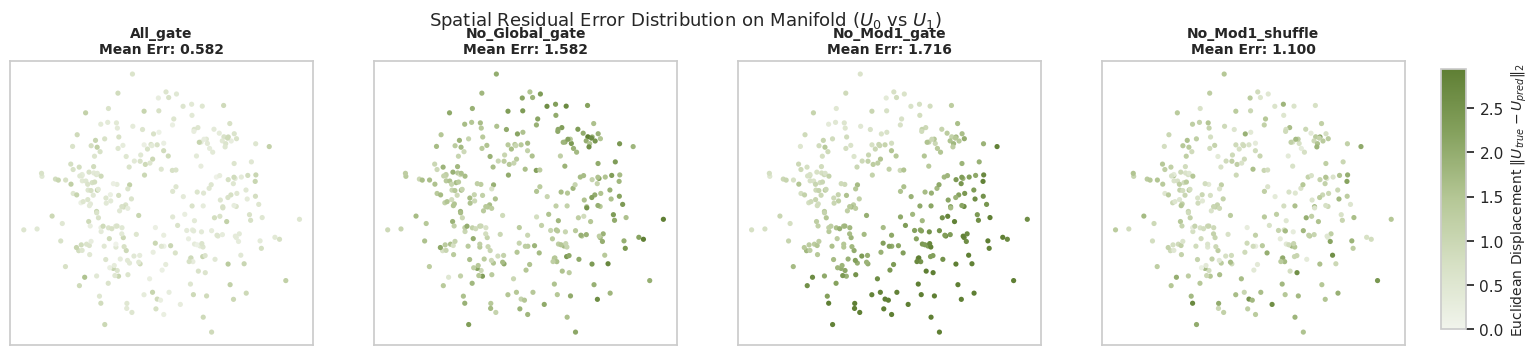

In [26]:
# ==============================================================================
# Step 10: Spatial Residual Displacement Heatmaps
# ==============================================================================
plot_conds = ["All_gate", "No_Global_gate", "No_Mod1_gate", "No_Mod1_shuffle"]
err_vectors = {c: np.linalg.norm(U_test_raw - ablation_preds[c], axis=1) for c in plot_conds}
vmax_err = np.percentile(np.concatenate(list(err_vectors.values())), 98)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.ravel()
last_sc = None

for i, c in enumerate(plot_conds):
    ax = axes[i]
    err = err_vectors[c]
    last_sc = ax.scatter(U_test_raw[:, 0], U_test_raw[:, 1], c=err, cmap=custom_green, s=14, vmin=0, vmax=vmax_err, linewidths=0)
    ax.set_title(f"{c}\nMean Err: {err.mean():.3f}", fontsize=10, fontweight="bold")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)

cbar_ax = fig.add_axes([0.92, 0.18, 0.014, 0.65])
cbar = fig.colorbar(last_sc, cax=cbar_ax)
cbar.set_label(r"Euclidean Displacement $\Vert U_{true} - U_{pred} \Vert_2$", fontsize=10)

plt.suptitle("Spatial Residual Error Distribution on Manifold ($U_0$ vs $U_1$)", fontsize=13, y=0.98)
plt.show()

## Theory: Error-Weighted State Averaging & Summary Metrics

To ground errors in continuous system observables $s_i$ (e.g., speed, frequency, order parameters), we calculate error-weighted averages:
$$\langle s \rangle_e = \frac{\sum_i e_i \cdot s_i}{\sum_i e_i}$$
Events with high reconstruction error dominate the weighted average, revealing which physical state regimes degrade under each ablation condition.

The final benchmark compares:
1. **Global $R^2$**: Variance-weighted reconstruction fidelity.
2. **RMSE**: Root-mean-squared error.
3. **Mean Manifold Displacement**: Average Euclidean error.
4. **Topological Preservation ($SI$)**: Structure Index of the continuous state variable in the reconstructed coordinate space.

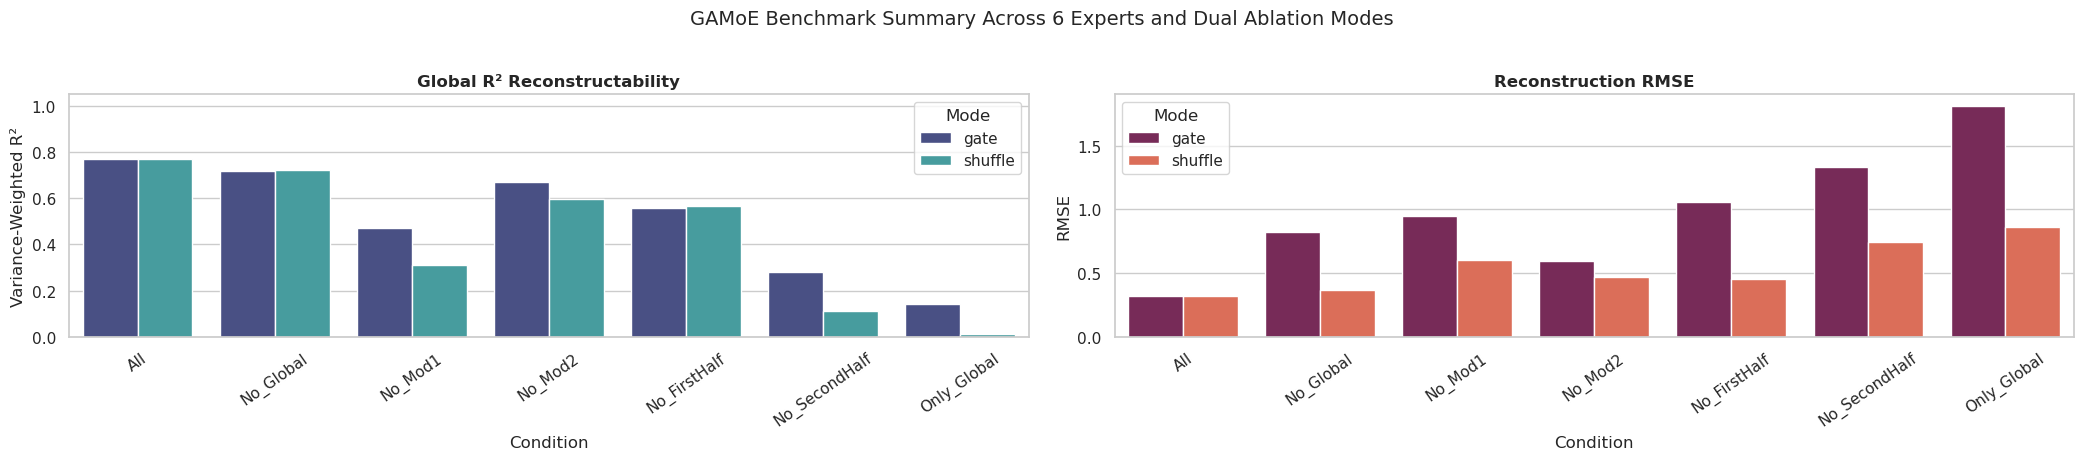

Final Summary Metrics (Pivot Table):


R2_Global            RMSE         Mean_Error          \
Mode               gate shuffle    gate shuffle       gate shuffle   
Condition                                                            
All              0.7700  0.7700  0.3207  0.3207     0.5821  0.5821   
No_FirstHalf     0.5565  0.5681  1.0604  0.4528     2.0242  0.8374   
No_Global        0.7186  0.7203  0.8240  0.3646     1.5821  0.6656   
No_Mod1          0.4709  0.3097  0.9495  0.6010     1.7162  1.1001   
No_Mod2          0.6697  0.5957  0.5943  0.4654     1.0345  0.8244   
No_SecondHalf    0.2802  0.1125  1.3297  0.7398     2.5287  1.3682   
Only_Global      0.1409  0.0115  1.8126  0.8585     3.5965  1.5881   

              SI_Covariate          
Mode                  gate shuffle  
Condition                           
All                 0.8052  0.8052  
No_FirstHalf        0.7875  0.7747  
No_Global           0.8119  0.8071  
No_Mod1             0.7963  0.7671  
No_Mod2             0.8023  0.7848  
No_SecondHalf       0.7789  0.7562  
Only_Global         0.7580  0.7532

In [27]:
# ==============================================================================
# Step 11: Final Multi-Metric Benchmark Comparison
# ==============================================================================
summary_records = []
si_baseline_true, _ = compute_structure_index(U_test_raw[:, :2], cov_test, n_bins=8, k=10, num_shuffles=0)

for key, Y_pred in ablation_preds.items():
    c_name, mode = key.rsplit("_", 1)
    r2, _, _ = compute_corr_r2_scores(U_test_raw, Y_pred)
    rmse = math.sqrt(mean_squared_error(U_test_raw, Y_pred))
    err = np.linalg.norm(U_test_raw - Y_pred, axis=1).mean()
    si_cov, _ = compute_structure_index(Y_pred[:, :2], cov_test, n_bins=8, k=10, num_shuffles=0)
    
    summary_records.append({
        "Condition": c_name,
        "Mode": mode,
        "R2_Global": r2,
        "RMSE": rmse,
        "Mean_Error": err,
        "SI_Covariate": si_cov
    })

df_sum = pd.DataFrame(summary_records)

fig, axes = plt.subplots(1, 2, figsize=(21, 4.5))

# 1. R2 Global
sns.barplot(data=df_sum, x="Condition", y="R2_Global", hue="Mode", palette="mako", ax=axes[0])
axes[0].set_title("Global R² Reconstructability", fontweight="bold")
axes[0].set_ylabel("Variance-Weighted R²")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=35)

# 2. RMSE
sns.barplot(data=df_sum, x="Condition", y="RMSE", hue="Mode", palette="rocket", ax=axes[1])
axes[1].set_title("Reconstruction RMSE", fontweight="bold")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle(f"GAMoE Benchmark Summary Across {N_EXPERTS} Experts and Dual Ablation Modes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Final Summary Metrics (Pivot Table):")
df_sum.pivot(index="Condition", columns="Mode", values=["R2_Global", "RMSE", "Mean_Error", "SI_Covariate"]).round(4)